<a href="https://colab.research.google.com/github/Yusuffff101/Yusuf-Bootwala/blob/main/EDA_Phase1_Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition — EDA Course Project (Phase 1)

**Dataset:** [Employee Attrition.csv](https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Employee%20Attrition.csv)

**Phase 1 tasks covered in this notebook:**
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (≥ 3 visualizations)
7. Bivariate analysis (≥ 3 visualizations)
8. Multivariate analysis (≥ 3 visualizations)

> Run all cells top to bottom (Runtime → Run all). This notebook is self-contained and only needs an internet connection to fetch the dataset directly from GitHub.


## 0. Import Libraries

In [1]:
# Core libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)


## 1. Loading the Dataset

The dataset is read directly from the raw GitHub URL, so no manual upload is required.


In [2]:
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Employee%20Attrition.csv"
df = pd.read_csv(url)

print("Shape of dataset (rows, columns):", df.shape)
df.head()


Shape of dataset (rows, columns): (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# Quick structural overview: column names, non-null counts, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 2. Basic Statistical Analysis

Summary statistics for numeric and categorical columns to understand the central
tendency, spread, and distribution of the data.


In [4]:
# Descriptive statistics for all NUMERIC columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
# Descriptive statistics for all CATEGORICAL (object) columns
df.describe(include="object").T


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [6]:
# Target variable distribution (class balance check)
print(df["Attrition"].value_counts())
print()
print(df["Attrition"].value_counts(normalize=True).round(3) * 100, "%")


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64 %


## 3. Handling Missing Data

Check for missing/null values across all columns and decide how to treat them.


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct.round(2)})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_summary)


No missing values found in the dataset.


In [8]:
# Defensive handling in case missing values ARE found when re-run on an updated dataset:
# - Numeric columns  -> fill with median (robust to outliers)
# - Categorical columns -> fill with mode (most frequent category)

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values remaining after handling:", df.isnull().sum().sum())


Missing values remaining after handling: 0


## 4. Data Cleaning

- Remove duplicate rows (if any)
- Drop columns that carry no analytical value (constant across all rows)
- Fix data types where appropriate


In [9]:
# Check and remove duplicate rows
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
df = df.drop_duplicates()


Number of duplicate rows: 0


In [10]:
# Identify columns with only ONE unique value — they add no information for EDA/modeling
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant (non-informative) columns:", constant_cols)

df_clean = df.drop(columns=constant_cols)
print("\nShape after dropping constant columns:", df_clean.shape)


Constant (non-informative) columns: ['EmployeeCount', 'Over18', 'StandardHours']

Shape after dropping constant columns: (1470, 32)


In [11]:
# Sanity check: unique values for a few categorical columns (helps spot inconsistent labels)
for c in ["Attrition", "BusinessTravel", "Department", "Gender", "OverTime"]:
    print(f"{c}: {df_clean[c].unique()}")


Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
Gender: ['Female' 'Male']
OverTime: ['Yes' 'No']


## 5. Data Transformation

- Encode the binary target (`Attrition`) as 0/1 for easier plotting and future modeling
- Create a few readable derived features (age groups, income in K) used later in the analysis
- Encode other Yes/No columns similarly


In [12]:
# Binary-encode Yes/No columns
binary_map = {"Yes": 1, "No": 0}
df_clean["Attrition_Flag"] = df_clean["Attrition"].map(binary_map)
df_clean["OverTime_Flag"] = df_clean["OverTime"].map(binary_map)

# Feature engineering: bucket Age into readable groups
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]
df_clean["AgeGroup"] = pd.cut(df_clean["Age"], bins=bins, labels=labels)

# Feature engineering: Monthly income expressed in thousands (easier to read on plots)
df_clean["MonthlyIncome_K"] = (df_clean["MonthlyIncome"] / 1000).round(1)

df_clean[["Age", "AgeGroup", "MonthlyIncome", "MonthlyIncome_K", "Attrition", "Attrition_Flag", "OverTime", "OverTime_Flag"]].head()


,Age,AgeGroup,MonthlyIncome,MonthlyIncome_K,Attrition,Attrition_Flag,OverTime,OverTime_Flag
0,41,36-45,5993,6.0,Yes,1,Yes,1
1,49,46-55,5130,5.1,No,0,No,0
2,37,36-45,2090,2.1,Yes,1,Yes,1
3,33,26-35,2909,2.9,No,0,Yes,1
4,27,26-35,3468,3.5,No,0,No,0


In [13]:
# Final cleaned & transformed dataset used for the rest of the analysis
df_final = df_clean.copy()
df_final.shape


(1470, 36)

## 6. Univariate Analysis
Examining the distribution of individual variables (minimum 3 visualizations).


### 6.1 Distribution of Employee Age

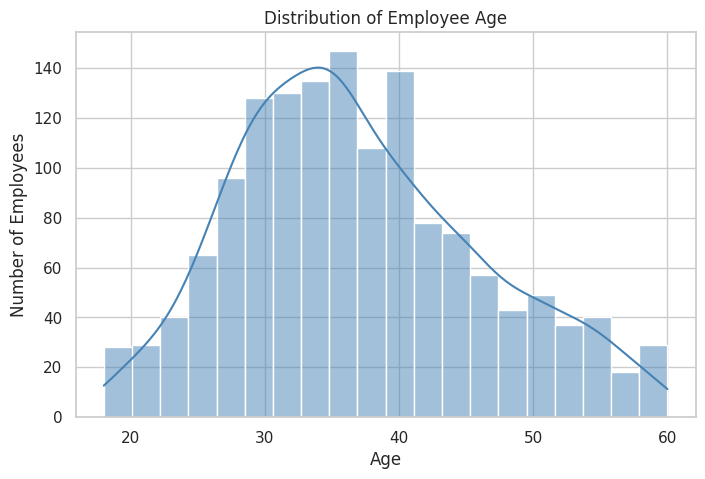

In [14]:
plt.figure()
sns.histplot(df_final["Age"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()


### 6.2 Attrition Count (Target Variable)

/tmp/ipykernel_2484/75770817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="Attrition", palette="Set2")


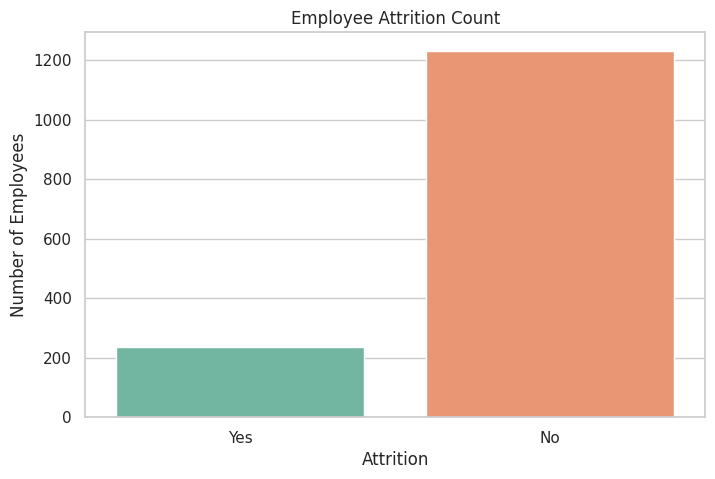

In [15]:
plt.figure()
sns.countplot(data=df_final, x="Attrition", palette="Set2")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


### 6.3 Spread of Monthly Income

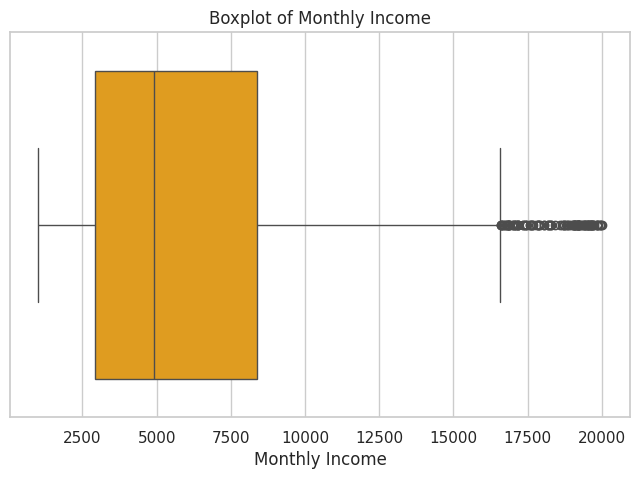

In [16]:
plt.figure()
sns.boxplot(data=df_final, x="MonthlyIncome", color="orange")
plt.title("Boxplot of Monthly Income")
plt.xlabel("Monthly Income")
plt.show()


### 6.4 Job Role Frequency (bonus)

/tmp/ipykernel_2484/882138231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, y="JobRole", order=order, palette="viridis")


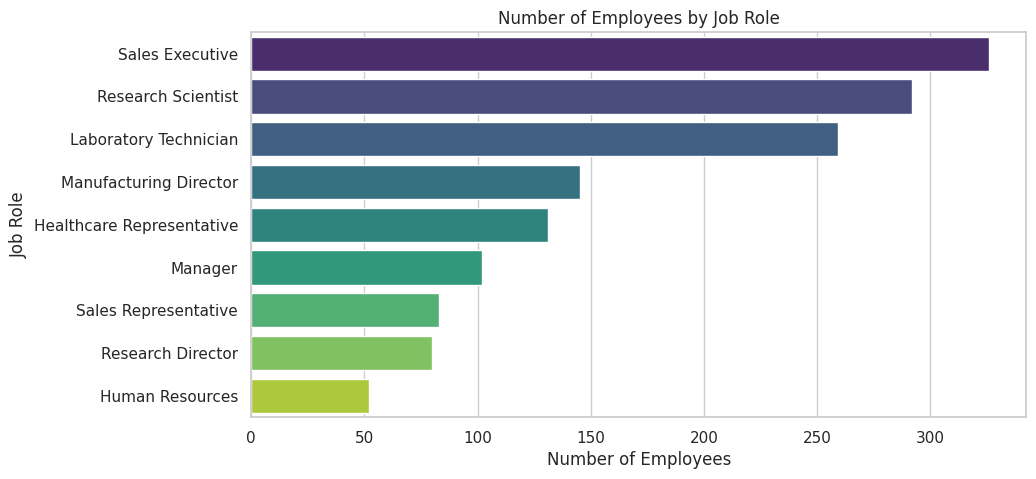

In [17]:
plt.figure(figsize=(10, 5))
order = df_final["JobRole"].value_counts().index
sns.countplot(data=df_final, y="JobRole", order=order, palette="viridis")
plt.title("Number of Employees by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.show()


## 7. Bivariate Analysis
Examining relationships between pairs of variables (minimum 3 visualizations).


### 7.1 Monthly Income vs Attrition

/tmp/ipykernel_2484/3047947254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="Attrition", y="MonthlyIncome", palette="Set3")


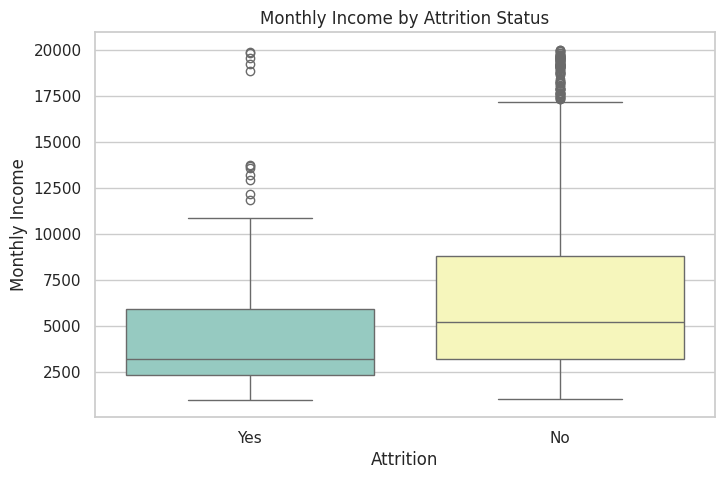

In [18]:
plt.figure()
sns.boxplot(data=df_final, x="Attrition", y="MonthlyIncome", palette="Set3")
plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()


### 7.2 OverTime vs Attrition

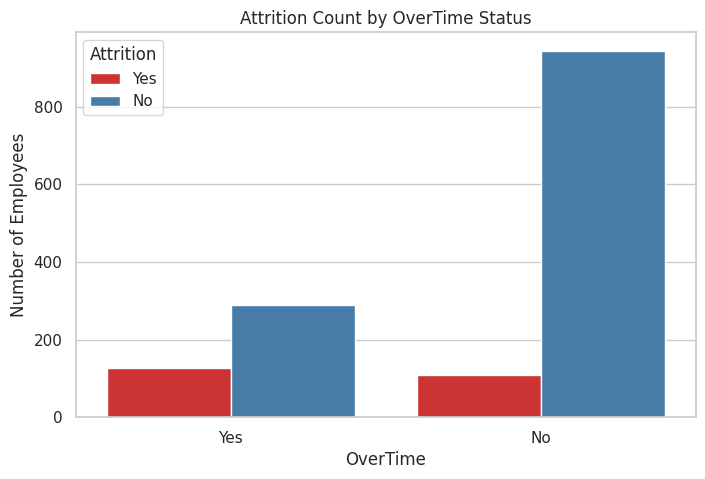

In [19]:
plt.figure()
sns.countplot(data=df_final, x="OverTime", hue="Attrition", palette="Set1")
plt.title("Attrition Count by OverTime Status")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()


### 7.3 Age vs Monthly Income

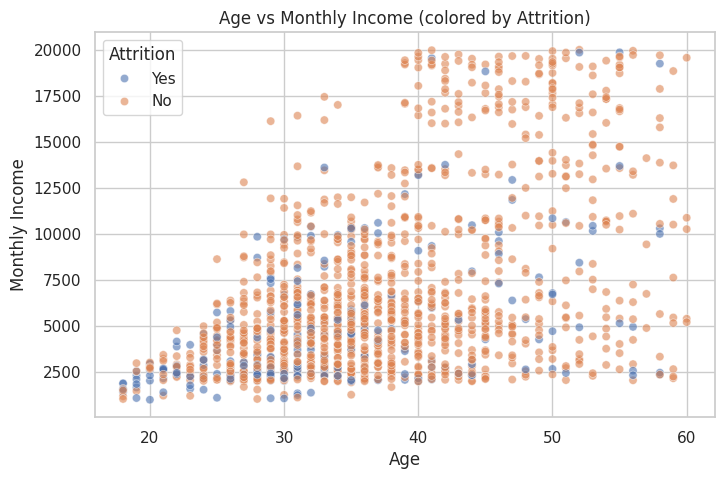

In [20]:
plt.figure()
sns.scatterplot(data=df_final, x="Age", y="MonthlyIncome", hue="Attrition", alpha=0.6)
plt.title("Age vs Monthly Income (colored by Attrition)")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.show()


### 7.4 Job Satisfaction vs Attrition (bonus)

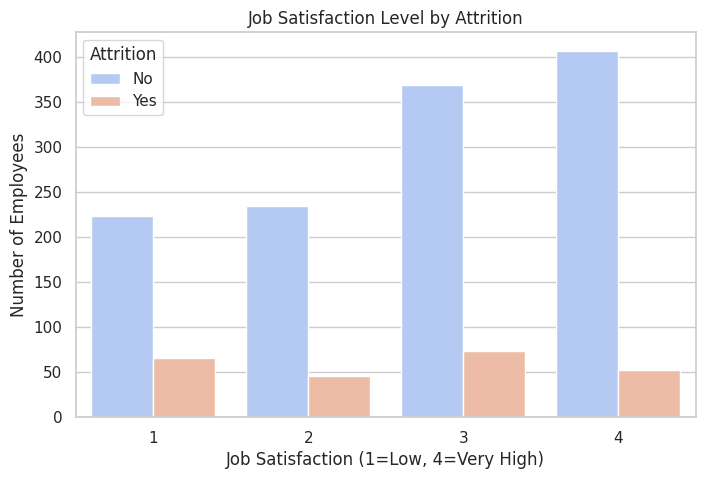

In [21]:
plt.figure()
sns.countplot(data=df_final, x="JobSatisfaction", hue="Attrition", palette="coolwarm")
plt.title("Job Satisfaction Level by Attrition")
plt.xlabel("Job Satisfaction (1=Low, 4=Very High)")
plt.ylabel("Number of Employees")
plt.show()


## 8. Multivariate Analysis
Examining relationships among three or more variables at once (minimum 3 visualizations).


### 8.1 Correlation Heatmap of Numeric Features

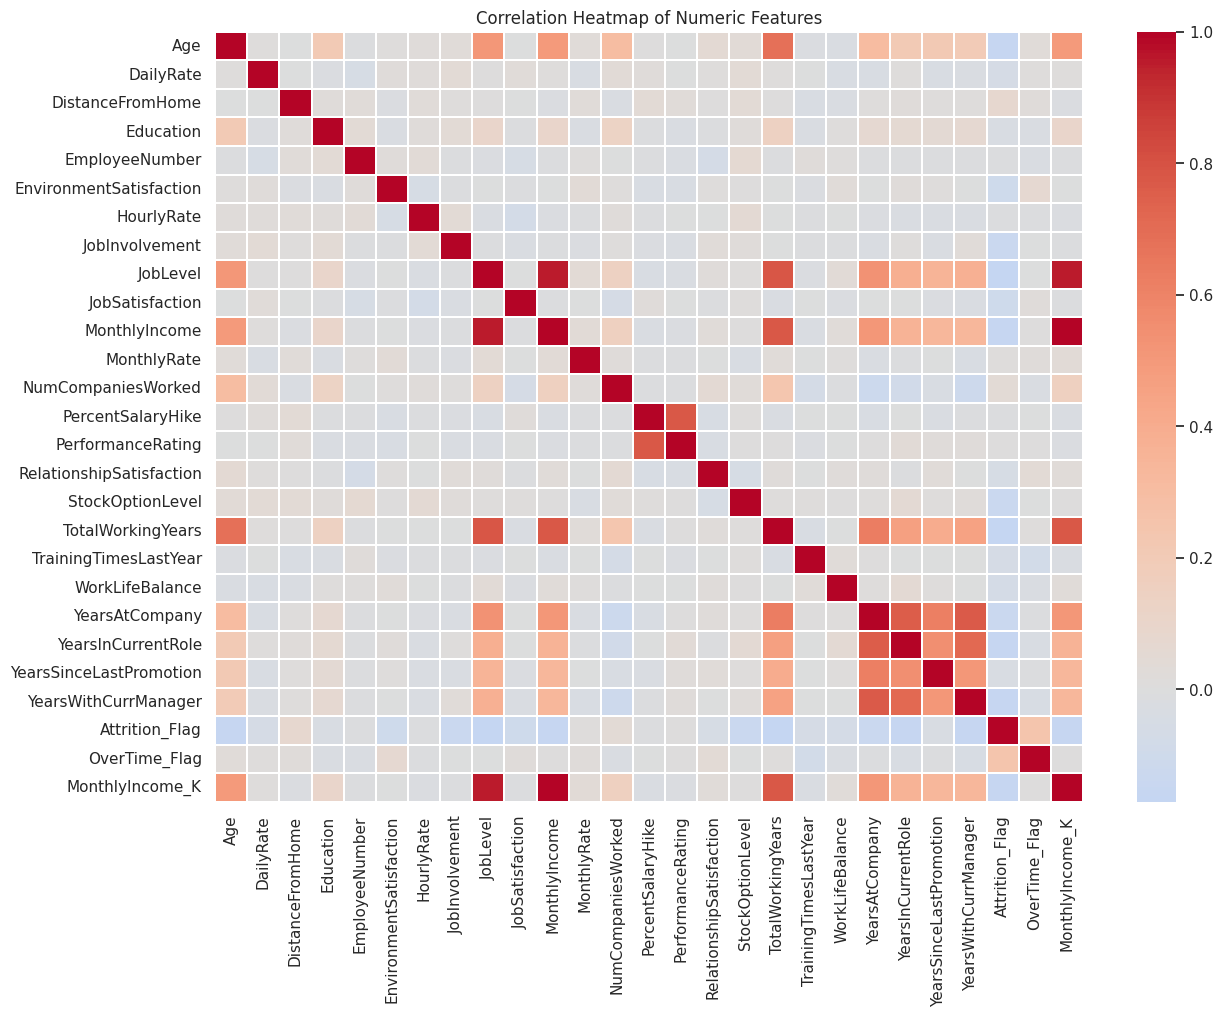

In [22]:
plt.figure(figsize=(14, 10))
numeric_df = df_final.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


### 8.2 Monthly Income by Department and Attrition

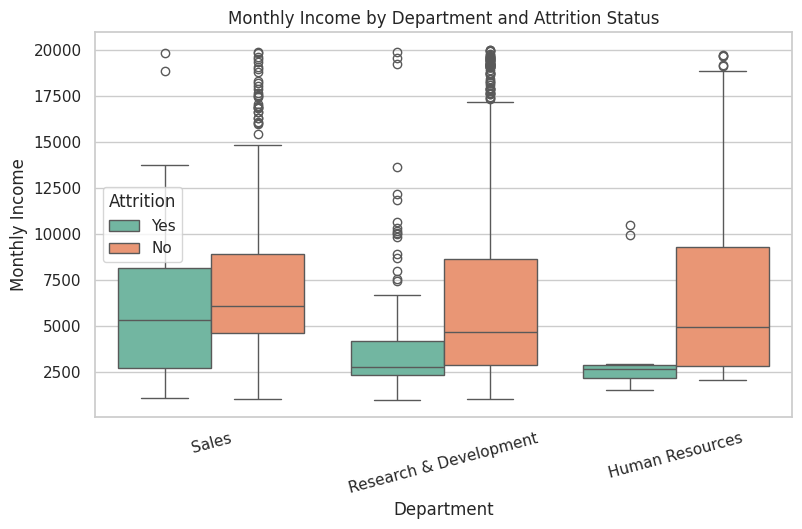

In [23]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_final, x="Department", y="MonthlyIncome", hue="Attrition", palette="Set2")
plt.title("Monthly Income by Department and Attrition Status")
plt.xlabel("Department")
plt.ylabel("Monthly Income")
plt.xticks(rotation=15)
plt.show()


### 8.3 Age, Monthly Income and Attrition (pairwise relationships)

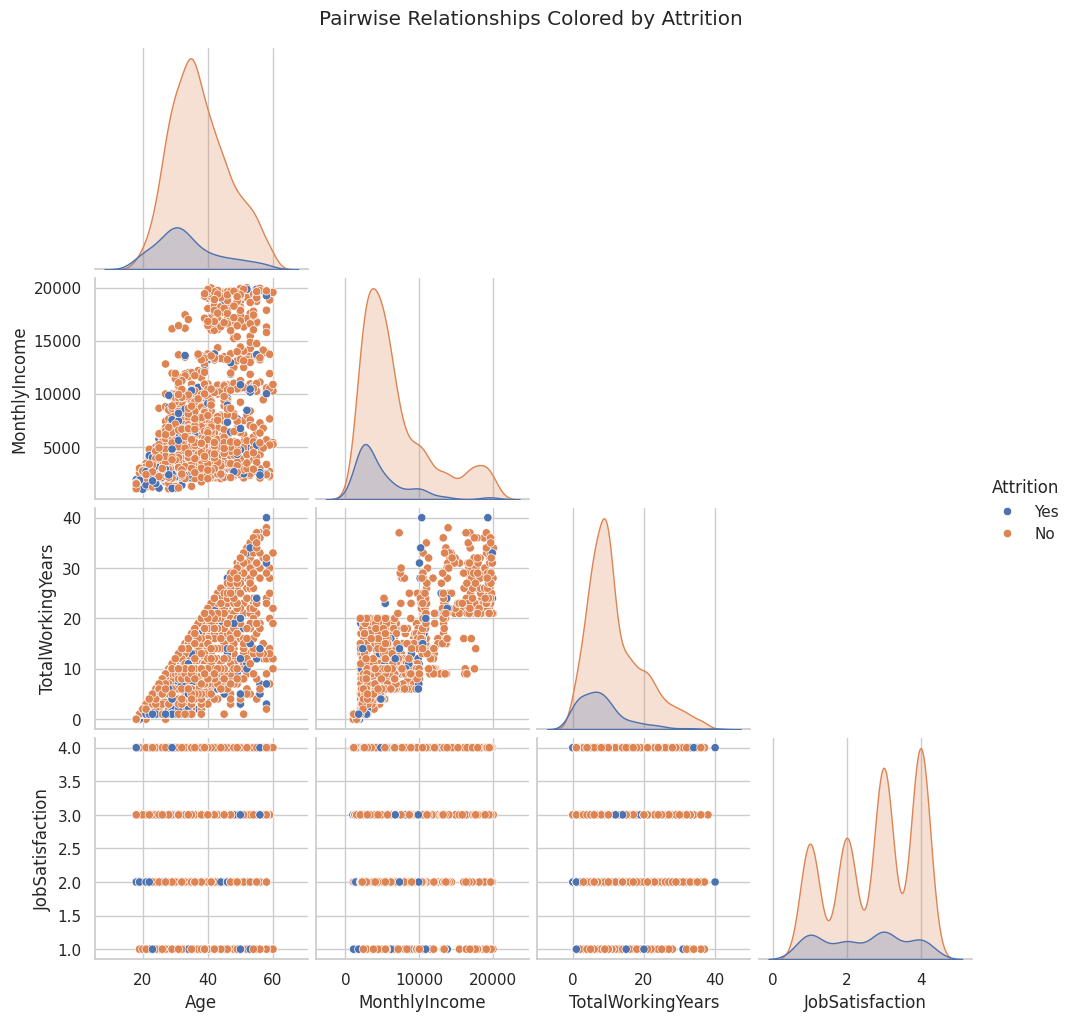

In [24]:
subset_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "JobSatisfaction", "Attrition"]
sns.pairplot(df_final[subset_cols], hue="Attrition", diag_kind="kde", corner=True)
plt.suptitle("Pairwise Relationships Colored by Attrition", y=1.02)
plt.show()


### 8.4 Attrition Rate by Department and Gender (bonus)

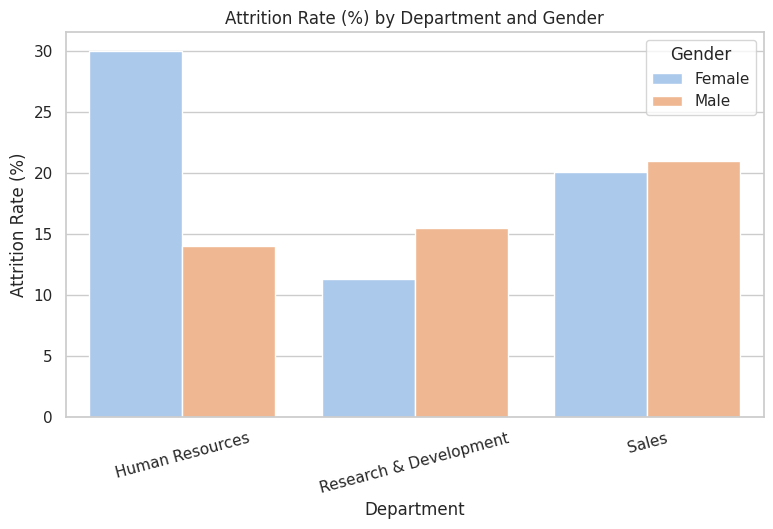

In [25]:
grouped = (
    df_final.groupby(["Department", "Gender"])["Attrition_Flag"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="AttritionRate(%)")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=grouped, x="Department", y="AttritionRate(%)", hue="Gender", palette="pastel")
plt.title("Attrition Rate (%) by Department and Gender")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)
plt.show()


## 9. Summary of Findings (Phase 1)

- The dataset contains **1470 employee records** with **35 original columns**; no missing values were found.
- Three constant columns (`EmployeeCount`, `StandardHours`, `Over18`) carried no analytical value and were dropped.
- Overall attrition rate is roughly **16%**, indicating class imbalance in the target variable.
- Employees who work **OverTime** show a noticeably higher attrition rate than those who don't.
- **Lower monthly income** and **lower job satisfaction** are visibly associated with higher attrition.
- The correlation heatmap highlights strong relationships between tenure-related features
  (e.g., `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`).

*These observations will be explored further with statistical testing and modeling in later phases of the project.*
